In [20]:
#Input the random seed ending * that identifies the run, from runcard_*.yaml
#Must be string and 3 characters, include 00 for 001, 002 etc.
random_seed_end = "001"

In [21]:
#Import functions and set design parameters
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib import rc
import glob as glob

from functions import *

plt.rcParams["axes.grid"] = False

rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=True)

#### Design properties ####
fScaling = 1.5 #Decides overall scaling of figures, 1 should be optimal
fWidth = fScaling*4.7747
fHeight = fScaling*3.81976
fontSize = 10.5*fScaling
fontSizeLegend = 9.5*fScaling

path_end = "_s*" + random_seed_end + ".dat"

path_start_1D = "../HI_Analysis/"
path_start_2D = "../HI_Analysis2D/"

# Table of Contents
- [1. $m_g^2$, $m_q^2$ and $T_*$](#1-mg2)
- [2. Scattering vs $t$](#2-scatter_split_merge_t)
- [3. Number of scatter/split/merge](#1-number_scatter_split_merge)

## 1. $m_g^2$, $m_q^2$ and $T_*$<a id="1-mg2"></a>
Show the screening mass and $T_*$ as a function of time.

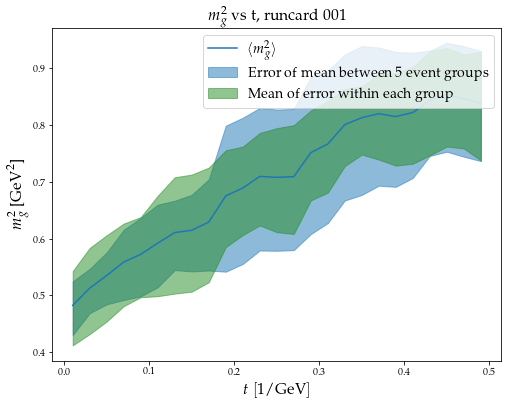

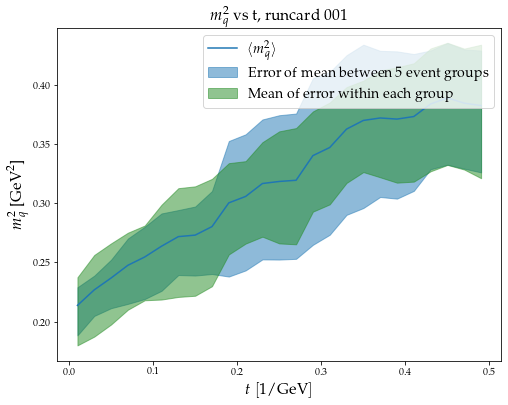

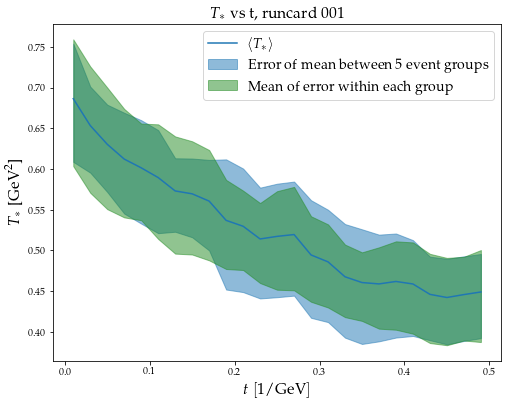

In [22]:
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'$m_g^2$ vs t, runcard ' + random_seed_end, fontsize=fontSize)
histo_name = "t+mg2"
x, y, y_err, y_err_2, eb_1, eb_2, N_groups = AverageFrom3DHisto(path_start_2D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, color='tab:blue', linewidth=1.5, label=r'$\langle m_g^2 \rangle$')
    plt.fill_between(x, eb_1[0], eb_1[1], alpha=0.5, edgecolor='tab:blue', facecolor='tab:blue', label=r'Error of mean between ' + str(N_groups) + ' event groups')
    plt.fill_between(x, eb_2[0], eb_2[1], alpha=0.5, edgecolor='forestgreen', facecolor='forestgreen', label=r'Mean of error within each group')
else:
    print("Could not find any data for histograms: " + histo_name)
plt.ylabel(r'$m_g^2$ [$\mathrm{GeV}^2$]', fontsize=fontSize)
plt.xlabel(r'$t$ $[1/\mathrm{GeV}]$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":fontSizeLegend})
plt.tight_layout()
    
    
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'$m_q^2$ vs t, runcard ' + random_seed_end, fontsize=fontSize)
histo_name = "t+mq2"
x, y, y_err, y_err_2, eb_1, eb_2, N_groups = AverageFrom3DHisto(path_start_2D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, color='tab:blue', linewidth=1.5, label=r'$\langle m_q^2 \rangle$')
    plt.fill_between(x, eb_1[0], eb_1[1], alpha=0.5, edgecolor='tab:blue', facecolor='tab:blue', label=r'Error of mean between ' + str(N_groups) + ' event groups')
    plt.fill_between(x, eb_2[0], eb_2[1], alpha=0.5, edgecolor='forestgreen', facecolor='forestgreen', label=r'Mean of error within each group')
else:
    print("Could not find any data for histograms: " + histo_name)
plt.ylabel(r'$m_q^2$ [$\mathrm{GeV}^2$]', fontsize=fontSize)
plt.xlabel(r'$t$ $[1/\mathrm{GeV}]$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":fontSizeLegend})
plt.tight_layout()
    

plt.figure(figsize=(fWidth,fHeight))
plt.title(r'$T_*$ vs t, runcard ' + random_seed_end, fontsize=fontSize)
histo_name = "t+Tstar"
x, y, y_err, y_err_2, eb_1, eb_2, N_groups = AverageFrom3DHisto(path_start_2D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, color='tab:blue', linewidth=1.5, label=r'$\langle T_* \rangle$')
    plt.fill_between(x, eb_1[0], eb_1[1], alpha=0.5, edgecolor='tab:blue', facecolor='tab:blue', label=r'Error of mean between ' + str(N_groups) + ' event groups')
    plt.fill_between(x, eb_2[0], eb_2[1], y+y_err_2, alpha=0.5, edgecolor='forestgreen', facecolor='forestgreen', label=r'Mean of error within each group')
else:
    print("Could not find any data for histograms: " + histo_name)
plt.ylabel(r'$T_*$ [$\mathrm{GeV}^2$]', fontsize=fontSize)
plt.xlabel(r'$t$ $[1/\mathrm{GeV}]$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":fontSizeLegend})
plt.tight_layout()

## 2. Scattering/split/merge vs. $t$<a id="2-scatter_split_merge_t"></a>
Mean number of scatterings, splittings and mergings binned in time $t$.

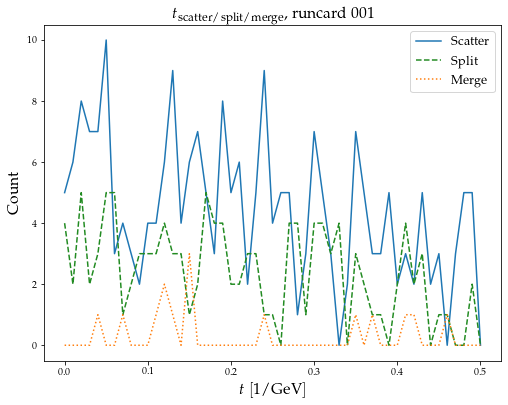

In [23]:
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'$t_{\mathrm{scatter/split/merge}}$, runcard ' + random_seed_end, fontsize=fontSize)
    
histo_name = "t_scatter"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, '-', color='tab:blue', linewidth=1.5, label =  r'Scatter')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "t_split"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, '--', color='forestgreen', linewidth=1.5, label = r'Split')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "t_merge"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y, ':',  color='tab:orange', linewidth=1.5, label = r'Merge')
else:
    print("Could not find any data for histograms: " + histo_name)
    
plt.ylabel(r'Count', fontsize=fontSize)
plt.xlabel(r'$t$ $[1/\mathrm{GeV}]$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":0.9*fontSizeLegend})
plt.tight_layout()

## 3. Number of scatterings per event<a id="3-number_split_merge"></a>
Mean total number of elastic scatterings per event as well as means of number of each type of scattering.

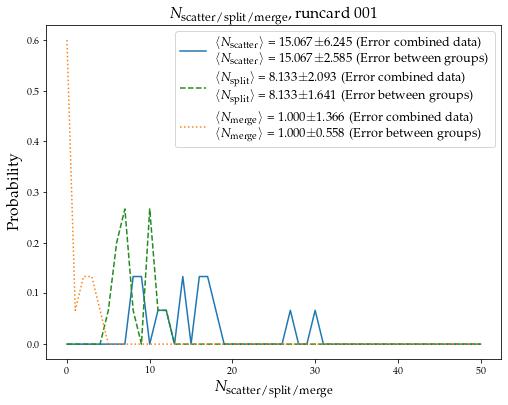

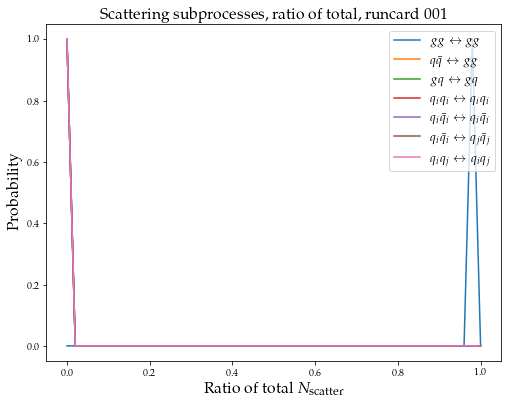

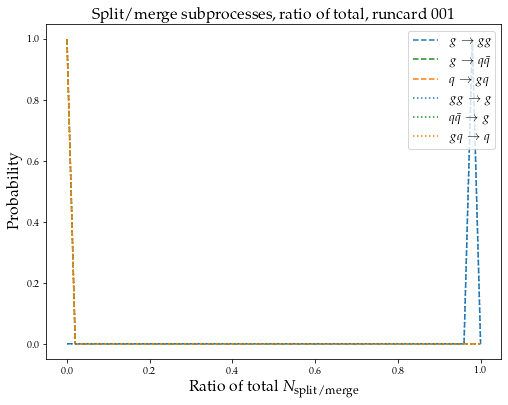

In [25]:
#Total scattering rates, normalized
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'$N_{\mathrm{scatter/split/merge}}$, runcard ' + random_seed_end, fontsize=fontSize)
    
histo_name = "N_scatter"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plot_label_1 = r'$\langle N_{\mathrm{scatter}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_2)+r' (Error combined data)'
    plot_label_2 = r'$\langle N_{\mathrm{scatter}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_1)+r' (Error between groups)'
    plt.plot(x, y/np.sum(y), '-', color='tab:blue', linewidth=1.5, label = plot_label_1 + '\n' + plot_label_2)
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_split"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plot_label_1 = r'$\langle N_{\mathrm{split}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_2)+r' (Error combined data)'
    plot_label_2 = r'$\langle N_{\mathrm{split}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_1)+r' (Error between groups)'
    plt.plot(x, y/np.sum(y), '--', color='forestgreen', linewidth=1.5, label = plot_label_1 + '\n' + plot_label_2)
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_merge"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plot_label_1 = r'$\langle N_{\mathrm{merge}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_2)+r' (Error combined data)'
    plot_label_2 = r'$\langle N_{\mathrm{merge}} \rangle$ = ' + r'{:.3f}'.format(y_mean) + r'$\pm$' + r'{:.3f}'.format(y_err_1)+r' (Error between groups)'
    plt.plot(x, y/np.sum(y), ':',  color='tab:orange', linewidth=1.5, label = plot_label_1 + '\n' + plot_label_2)
else:
    print("Could not find any data for histograms: " + histo_name)
    
plt.ylabel(r'Probability', fontsize=fontSize)
plt.xlabel(r'$N_{\mathrm{scatter/split/merge}}$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":0.9*fontSizeLegend})
plt.tight_layout()

#Subprocesses scattering
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'Scattering subprocesses, ratio of total, runcard ' + random_seed_end, fontsize=fontSize)
    
histo_name = "N_scatter_ratio_gg_gg"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$gg \leftrightarrow gg$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_qqb_gg"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$q\bar{q} \leftrightarrow gg$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_gq_gq"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$gq \leftrightarrow gq$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_qiqi_qiqi"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$q_iq_i \leftrightarrow q_iq_i$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_qiqib_qiqib"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$q_i\bar{q}_i \leftrightarrow q_i\bar{q}_i$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_qiqib_qjqjb"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$q_i\bar{q}_i \leftrightarrow q_j\bar{q}_j$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_scatter_ratio_qiqj_qiqj"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), linewidth=1.5, label = r'$q_iq_j \leftrightarrow q_iq_j$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
plt.ylabel(r'Probability', fontsize=fontSize)
plt.xlabel(r'Ratio of total $N_{\mathrm{scatter}}$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":0.9*fontSizeLegend})
plt.tight_layout()


#Subprocesses splitting/merging
plt.figure(figsize=(fWidth,fHeight))
plt.title(r'Split/merge subprocesses, ratio of total, runcard ' + random_seed_end, fontsize=fontSize)
    
histo_name = "N_split_ratio_ggg"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), '--', color='tab:blue', linewidth=1.5, label = r'$g\rightarrow gg$')
else:
    print("Could not find any data for histograms: " + histo_name)

histo_name = "N_split_ratio_gqq"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), '--', color='forestgreen', linewidth=1.5, label = r'$g\rightarrow q\bar{q}$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_split_ratio_qgq"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), '--', color='tab:orange', linewidth=1.5, label = r'$q\rightarrow gq$')
else:
    print("Could not find any data for histograms: " + histo_name)
    

histo_name = "N_merge_ratio_ggg"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), ':', color='tab:blue', linewidth=1.5, label = r'$gg\rightarrow g$')
else:
    print("Could not find any data for histograms: " + histo_name)

histo_name = "N_merge_ratio_gqq"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), ':', color='forestgreen', linewidth=1.5, label = r'$q\bar{q}\rightarrow g$')
else:
    print("Could not find any data for histograms: " + histo_name)
    
histo_name = "N_merge_ratio_qgq"
x, y, y_mean, y_err_1, y_err_2, N_groups = Plot2D(path_start_1D + histo_name + path_end)
if N_groups > 0:
    plt.plot(x, y/np.sum(y), ':', color='tab:orange', linewidth=1.5, label = r'$gq\rightarrow q$')
else:
    print("Could not find any data for histograms: " + histo_name)

    
    
plt.ylabel(r'Probability', fontsize=fontSize)
plt.xlabel(r'Ratio of total $N_{\mathrm{split/merge}}$', fontsize=fontSize)
plt.legend(loc="upper right",prop={"size":0.9*fontSizeLegend})
plt.tight_layout()